In [1]:
#install.packages("neuralnet")
library(neuralnet)

In [2]:
d <- read.csv("Smarket.csv", header = TRUE)
d <- d[,-c(1,8)]
d[,-7] <- scale(d[,-7])
head(d)

,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Up
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,0.3319247,-0.1724215,-2.3058832,-0.9278718,4.3609337,-0.7964461,TRUE
2,0.8405937,0.3318555,-0.1701199,-2.3056696,-0.9242381,-0.5045135,TRUE
3,0.9048373,0.8405328,0.3330842,-0.1700390,-2.2914985,-0.1862181,FALSE
4,-0.5516457,0.9047775,0.8406793,0.3331338,-0.1722013,-0.5614015,TRUE
5,0.5369763,-0.5517294,0.9047873,0.8406973,0.3271233,-0.7564857,TRUE
6,0.1840762,0.5369105,-0.5486207,0.9048013,0.8308050,-0.3585471,TRUE


In [3]:
n.train <- floor(nrow(d)*.8)
set.seed(1000)
ind.train <- sample(1:nrow(d), n.train)
data.train <- d[ind.train,]
data.test <- d[-ind.train,]

In [4]:
nn <- neuralnet(Up ~ Lag1+Lag2, data = data.train, hidden = 2, linear.output = FALSE)
load("Smarket_nn1.Rda")

[[1]]
[[1]][[1]]
           [,1]       [,2]
[1,] -1.5526810 -20.092955
[2,] -0.4006151   1.325688
[3,]  0.3979986  33.606746

[[1]][[2]]
           [,1]
[1,] -0.2670554
[2,]  2.5133068
[3,] -0.7918837

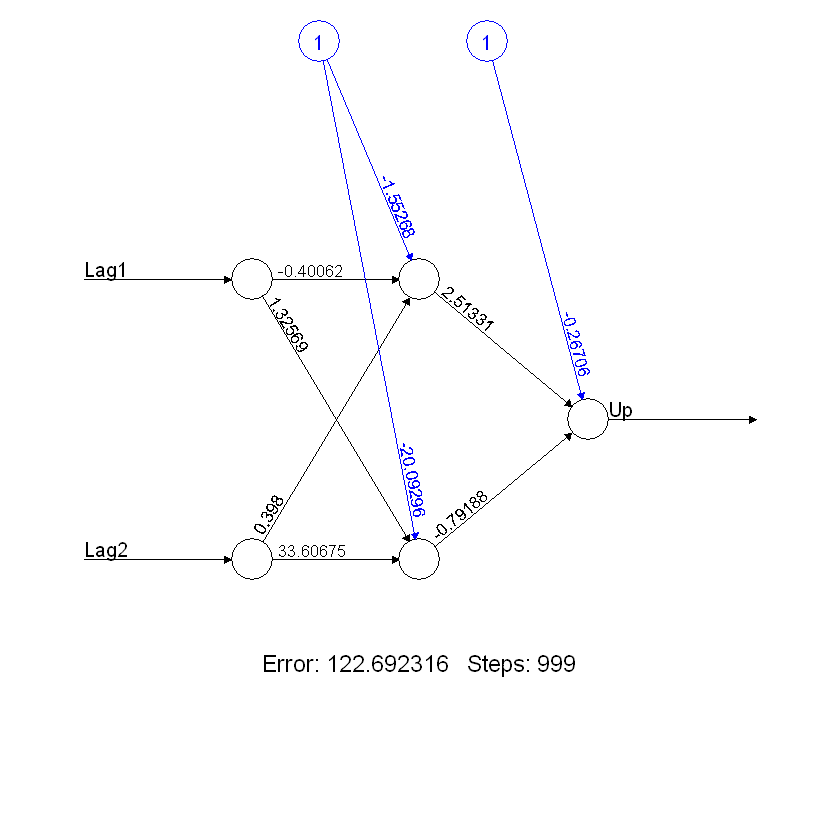

In [5]:
plot(nn, rep = "best")
nn$weights

In [6]:
data.test[1,]

,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Up
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
4,-0.5516457,0.9047775,0.8406793,0.3331338,-0.1722013,-0.5614015,TRUE


In [7]:
s1 <- (-1.5526810)+(-0.4006151)*(-0.5516457)+(0.3979986)*(0.9047775)
s1 <- exp(s1)/(1+exp(s1))
s1

s2 <- (-20.092955)+(1.325688)*(-0.5516457)+(33.606746)*(0.9047775)
s2 <- exp(s2)/(1+exp(s2))
s2

[1] 0.274565

[1] 0.9999311

In [8]:
p1 <- (-0.2670554)+(2.5133068)*(s1)+(-0.7918837)*(s2)
p1 <- exp(p1)/(1+exp(p1))
p1

[1] 0.4088266

In [9]:
compute(nn, data.test[1,])

$neurons
$neurons[[1]]
          Lag1      Lag2
4 1 -0.5516457 0.9047775

$neurons[[2]]
  [,1]     [,2]      [,3]
4    1 0.274565 0.9999311


$net.result
       [,1]
4 0.4088266

In [10]:
#nn <- neuralnet(Up ~., data = data.train, hidden = c(4,2), linear.output = FALSE)
load("Smarket_nn2.Rda")

[[1]]
[[1]][[1]]
           [,1]       [,2]       [,3]      [,4]
[1,]  24.941304  4.4706848   5.009676 10.777490
[2,]  -7.772401  0.8494812  47.066175 -8.847193
[3,]   1.298680 12.6041290  22.221023 38.656984
[4,]  20.287595 -7.2960691 -18.176239 -2.514204
[5,]  10.153700  3.5896858  33.039056  8.634679
[6,] -28.238790  7.1446356 -31.196677  2.621653
[7,]   1.357078  5.5467796 -12.241043 17.203489

[[1]][[2]]
           [,1]       [,2]
[1,]  -3.365781  19.296141
[2,] -11.870508 -32.678922
[3,] -13.111699 -43.937652
[4,]  10.874750  12.787581
[5,]  16.638593  -5.250724

[[1]][[3]]
           [,1]
[1,]  0.6486364
[2,] -1.8770666
[3,] -2.5122171

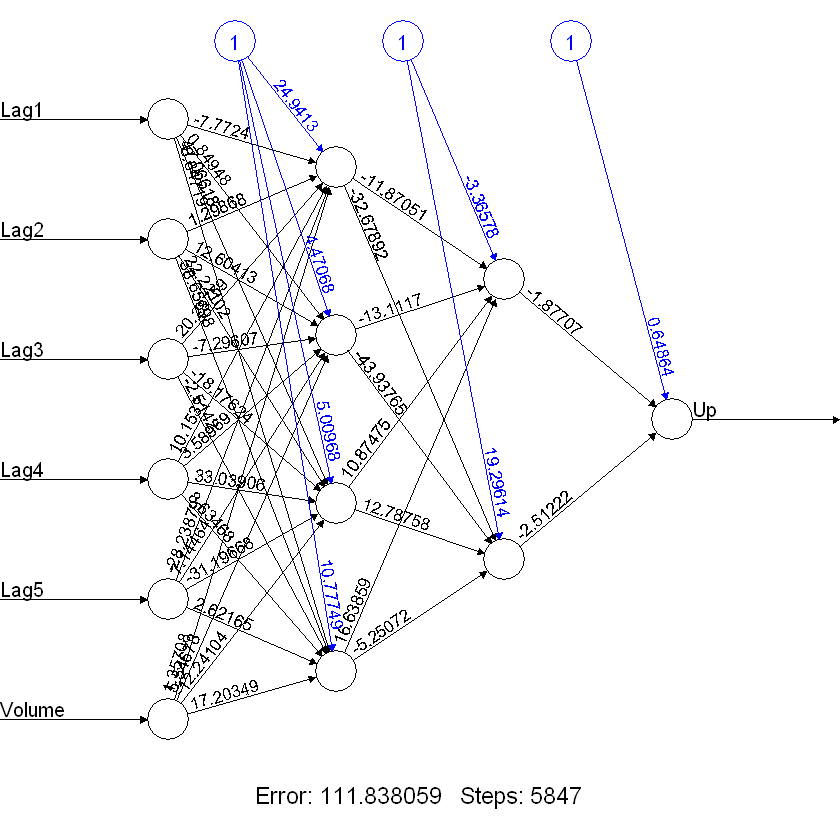

In [11]:
plot(nn, rep="best")
nn$weights

In [12]:
pred <- compute(nn, data.test)
pred$net.result

4,0.51814538
12,0.29861150
14,0.65513825
17,0.43358310
20,0.52013162
35,0.65670214
37,0.40969461
39,0.24821790
53,0.48620081
60,0.65670214
61,0.65514257


In [13]:
pred.class <- rep(FALSE, nrow(data.test))
pred.class[pred$net.result>.5] <- TRUE
confusion <- table(pred.class, data.test$Up)
confusion

          
pred.class FALSE TRUE
     FALSE    38   42
     TRUE     73   97

In [14]:
sum(diag(confusion)) / sum(confusion)

[1] 0.54

In [15]:
# 1. Fit the logistic regression model using all available predictors
glm.fit <- glm(Up ~ ., data = data.train, family = binomial)

# 2. Predict the probabilities of "Up" for the testing set
glm.probs <- predict(glm.fit, newdata = data.test, type = "response")

# 3. Determine predicted market performance using 0.5 as the cutoff
glm.pred <- rep(FALSE, nrow(data.test))
glm.pred[glm.probs > 0.5] <- TRUE

# 4. Construct the confusion matrix
glm.confusion <- table(glm.pred, data.test$Up)
print("Confusion Matrix:")
print(glm.confusion)

# 5. Calculate the out-of-sample prediction accuracy
glm.accuracy <- sum(diag(glm.confusion)) / sum(glm.confusion)
print(paste("Logistic Regression Accuracy:", glm.accuracy))

[1] "Confusion Matrix:"
        
glm.pred FALSE TRUE
   FALSE    47   57
   TRUE     64   82
[1] "Logistic Regression Accuracy: 0.516"


In [16]:
summary(glm.fit)



Call:
glm(formula = Up ~ ., family = binomial, data = data.train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)  
(Intercept)  0.036503   0.063559   0.574   0.5658  
Lag1        -0.151514   0.065864  -2.300   0.0214 *
Lag2        -0.071780   0.065694  -1.093   0.2745  
Lag3         0.007196   0.065537   0.110   0.9126  
Lag4         0.006637   0.066380   0.100   0.9204  
Lag5         0.046465   0.064486   0.721   0.4712  
Volume       0.085079   0.064350   1.322   0.1861  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1386.0  on 999  degrees of freedom
Residual deviance: 1377.6  on 993  degrees of freedom
AIC: 1391.6

Number of Fisher Scoring iterations: 4
